In [1]:
from pathlib import Path
import os, fnmatch
import datetime, calendar, time
from pytz import utc
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import pandas as pd
import datetime
import copy
import seaborn as sns
from sklearn.neighbors import KernelDensity
from scipy.stats import pearsonr, spearmanr, linregress
from matplotlib import gridspec
import colorcet as cc

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/'

# CSAPR data directory
# dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/'
dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/'
dir_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/'
dir_pixel_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_gridded.c1/'
dir_pixel_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/celltracking/'
# dir_pixel_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqcM1_gridded_convmask.c1/'
terrain_file = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/corgridded_terrain.c0/topo_cacti_csapr2_large.nc'
radar_lat = -32.1264
radar_lon = -64.7284
# Start/end hours for OBS
# shour_obs = '09'
# ehour_obs = '03'
shour_obs = '12'
ehour_obs = '00'

# basename_obs = 'csapr_trackstats_'
basename_obs = 'trackstats_'
basename_obs25 = 'trackstats_'
sat_basename = 'stats_goes16_'
# statsfiles_obs = sorted(glob.glob(f'{dir_obs}{basename_obs}*nc'))
# statsfiles_obs

statsfiles_obs = []
statsfiles_obs25 = []
satfiles_obs = []
satfiles_obs25 = []
for idate in start_dates:
    statsfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{basename_obs}{idate}*nc')))
    statsfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{basename_obs25}{idate}*nc')))
    satfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{sat_basename}{idate}*nc')))
    satfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{sat_basename}{idate}*nc')))

print(f'Number of cases (OBS): {len(statsfiles_obs)}')
print(f'Number of cases (OBS 2.5km): {len(statsfiles_obs25)}')
print(f'Number of satellite files (OBS): {len(satfiles_obs)}')
print(f'Number of satellite (OBS 2.5km): {len(satfiles_obs25)}')
statsfiles_obs, statsfiles_obs25, satfiles_obs, satfiles_obs25

Number of cases (OBS): 8
Number of cases (OBS 2.5km): 8
Number of satellite files (OBS): 8
Number of satellite (OBS 2.5km): 8


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfr

In [4]:
# LASSO regridded cloud file basename for calculating total "scan" times
# cld_basename = 'corlasso.cldhamsl.'
cld_basename = 'corlasso_cldhamsl_'

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
# LASSO staged data directory
lassodir = '/gpfs/wolf2/arm/cli120/world-shared/d3m088/cacti/staged_runs/'
in_basename = 'trackstats_20'
in_basename_tb = 'stats_tb_'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
lon_range = [-64.9, -63.3]
lat_range = [-33., -30.8]
lifetime_range = [30, 1000]  # [min]

# Find LASSO files
# statsfiles_d2 = find_lasso_stats_files(start_dates, rootdir_meso, in_basename, 'd2')
# statsfiles_d3 = find_lasso_stats_files(start_dates, rootdir_les, in_basename, 'd3')
# statsfiles_d4 = find_lasso_stats_files(start_dates, rootdir_les, in_basename, 'd4_15min')
statsfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2_15min')
statsfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3_15min')
statsfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min')
satfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_tb, 'd2_15min')
satfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_tb, 'd3_15min')
satfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_tb, 'd4_15min')

print(f'Number of stats files (D2): {len(statsfiles_d2)}')
print(f'Number of stats files (D3): {len(statsfiles_d3)}')
print(f'Number of stats files (D4): {len(statsfiles_d4)}')
print(f'Number of tb files (D2): {len(satfiles_d2)}')
print(f'Number of tb files (D3): {len(satfiles_d3)}')
print(f'Number of tb files (D4): {len(satfiles_d4)}')
statsfiles_d2, statsfiles_d3, statsfiles_d4

Number of stats files (D2): 17
Number of stats files (D3): 17
Number of stats files (D4): 17
Number of tb files (D2): 17
Number of tb files (D3): 17
Number of tb files (D4): 17


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2_15min/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfe

In [5]:
satfiles_d2, satfiles_d3, satfiles_d4

(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2_15min/stats/stats_tb_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2_15min/stats/stats_tb_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2_15min/stats/stats_tb_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2_15min/stats/stats_tb_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2_15min/stats/stats_tb_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2_15min/stats/stats_tb_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2_15min/stats/stats_tb_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/

## Read track stats files

In [6]:
# Read track data (OBS)
dst_o = xr.open_mfdataset(statsfiles_obs, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_o = dst_o.sizes['tracks']
dst_o['tracks'] = np.arange(0, ntracks_o)
print(f'Number of tracks (OBS): {ntracks_o}')

# Read satellite data
dssat_o = xr.open_mfdataset(satfiles_obs, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dssat_o['tracks'] = np.arange(0, ntracks_o)

# Combine datasets by coordinates
ds_o = xr.combine_by_coords([dst_o, dssat_o], combine_attrs='drop_conflicts')
ds_o

Number of tracks (OBS): 542


<xarray.Dataset> Size: 5MB
Dimensions:                    (tracks: 542, times: 60)
Coordinates:
  * tracks                     (tracks) int64 4kB 0 1 2 3 4 ... 538 539 540 541
  * times                      (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/45)
    track_duration             (tracks) int32 2kB dask.array<chunksize=(62,), meta=np.ndarray>
    base_time                  (tracks, times) datetime64[ns] 260kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlat                    (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlon                    (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area                       (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    cloudnumber                (tracks, times) float64 260kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                         ...
    cloud_top_height_max       (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    cloud_top_pressure_min     (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area_liquid                (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area_ice                   (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    lwp_max                    (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    iwp_max                    (tracks, times) float32 130kB dask.array<chunksize=(1, 60), meta=np.ndarray>
Attributes:
    Title:                 Statistics of each track
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5
    title:                 GOES16 cell track statistics
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csa...

In [7]:
# Read track data (OBS 2.5km)
dst_o25 = xr.open_mfdataset(statsfiles_obs25, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_o25 = dst_o25.sizes['tracks']
dst_o25['tracks'] = np.arange(0, ntracks_o25)
print(f'Number of tracks (OBS 2.5km): {ntracks_o25}')

# Read satellite data
dssat_o25 = xr.open_mfdataset(satfiles_obs25, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dssat_o25['tracks'] = np.arange(0, ntracks_o25)

# Combine datasets by coordinates
ds_o25 = xr.combine_by_coords([dst_o25, dssat_o25], combine_attrs='drop_conflicts')
# ds_o25

Number of tracks (OBS 2.5km): 503


In [8]:
# Read track data (D2)
dst_d2 = xr.open_mfdataset(statsfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read Tb data
dssat_d2 = xr.open_mfdataset(satfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dssat_d2['tracks'] = np.arange(0, ntracks_d2)

# Combine datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dssat_d2], combine_attrs='drop_conflicts')
ds_d2

Number of tracks (D2): 3923


<xarray.Dataset> Size: 32MB
Dimensions:                  (tracks: 3923, times: 60)
Coordinates:
  * tracks                   (tracks) int64 31kB 0 1 2 3 ... 3919 3920 3921 3922
  * times                    (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/39)
    cell_area                (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    OLR_min                  (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    temperature_ir_min       (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 2MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    track_duration           (tracks) int32 16kB dask.array<chunksize=(144,), meta=np.ndarray>
    meanlat                  (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell cloud-top statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

In [9]:
# Read track data (D3)
dst_d3 = xr.open_mfdataset(statsfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read Tb data
dssat_d3 = xr.open_mfdataset(satfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dssat_d3['tracks'] = np.arange(0, ntracks_d3)

# Combine datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dssat_d3], combine_attrs='drop_conflicts')
ds_d3

Number of tracks (D3): 5401


<xarray.Dataset> Size: 45MB
Dimensions:                  (tracks: 5401, times: 60)
Coordinates:
  * tracks                   (tracks) int64 43kB 0 1 2 3 ... 5397 5398 5399 5400
  * times                    (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/39)
    cell_area                (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    OLR_min                  (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    temperature_ir_min       (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 3MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    track_duration           (tracks) int32 22kB dask.array<chunksize=(205,), meta=np.ndarray>
    meanlat                  (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 43kB dask.array<chunksize=(205,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 43kB dask.array<chunksize=(205,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 43kB dask.array<chunksize=(205,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 43kB dask.array<chunksize=(205,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 43kB dask.array<chunksize=(205,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 43kB dask.array<chunksize=(205,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell cloud-top statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

In [10]:
# Read track data (D4)
dst_d4 = xr.open_mfdataset(statsfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read Tb data
dssat_d4 = xr.open_mfdataset(satfiles_d4, concat_dim='tracks', combine='nested')
# Drop cell_area (because in the Tb file it is calculated at native 100m, where in the tracking it is calculated at 500m, the values are slightly different)
# dropping this avoids conflict when combining the data
dssat_d4 = dssat_d4.drop_vars('cell_area')
# Renumber tracks to make it continuous
dssat_d4['tracks'] = np.arange(0, ntracks_d4)

# Combine datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dssat_d4], combine_attrs='drop_conflicts')
ds_d4

Number of tracks (D4): 4239


<xarray.Dataset> Size: 116MB
Dimensions:                  (tracks: 4239, times: 200)
Coordinates:
  * tracks                   (tracks) int64 34kB 0 1 2 3 ... 4235 4236 4237 4238
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
Data variables: (12/39)
    OLR_min                  (tracks, times) float32 3MB dask.array<chunksize=(1, 200), meta=np.ndarray>
    temperature_ir_min       (tracks, times) float32 3MB dask.array<chunksize=(1, 200), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 7MB dask.array<chunksize=(1, 200), meta=np.ndarray>
    track_duration           (tracks) int32 17kB dask.array<chunksize=(147,), meta=np.ndarray>
    meanlat                  (tracks, times) float32 3MB dask.array<chunksize=(1, 200), meta=np.ndarray>
    meanlon                  (tracks, times) float32 3MB dask.array<chunksize=(1, 200), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 34kB dask.array<chunksize=(147,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 34kB dask.array<chunksize=(147,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 34kB dask.array<chunksize=(147,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 34kB dask.array<chunksize=(147,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 34kB dask.array<chunksize=(147,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 34kB dask.array<chunksize=(147,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell cloud-top statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

## Subset tracks

In [11]:
def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    # start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) 
        # (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [12]:
time_res = 15.0  # [min]

ds_o_s, track_idx = subset_tracks(ds_o, time_res, lon_range, lat_range, lifetime_range)
ntracks_o = ds_o_s.sizes['tracks']
print(f'Number of tracks (OBS): {ntracks_o}')

Number of tracks (OBS): 246


In [13]:
ds_o25_s, track_idx = subset_tracks(ds_o25, time_res, lon_range, lat_range, lifetime_range)
ntracks_o25 = ds_o25_s.sizes['tracks']
print(f'Number of tracks (OBS 2.5km): {ntracks_o25}')

Number of tracks (OBS 2.5km): 215


In [14]:
ds_d2_s, track_idx = subset_tracks(ds_d2, time_res, lon_range, lat_range, lifetime_range)
ntracks_d2 = ds_d2_s.sizes['tracks']
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 1056


In [15]:
ds_d3_s, track_idx = subset_tracks(ds_d3, time_res, lon_range, lat_range, lifetime_range)
ntracks_d3 = ds_d3_s.sizes['tracks']
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 1321


In [16]:
ds_d4_s, track_idx = subset_tracks(ds_d4, time_res, lon_range, lat_range, lifetime_range)
ntracks_d4 = ds_d4_s.sizes['tracks']
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 1252


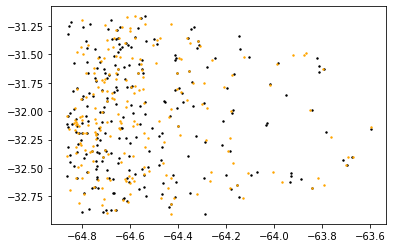

In [17]:
plt.scatter(ds_o_s['meanlon'].mean(dim='times'), ds_o_s['meanlat'].mean(dim='times'), s=2, c='k')
plt.scatter(ds_o25_s['meanlon'].mean(dim='times'), ds_o25_s['meanlat'].mean(dim='times'), s=2, c='orange')

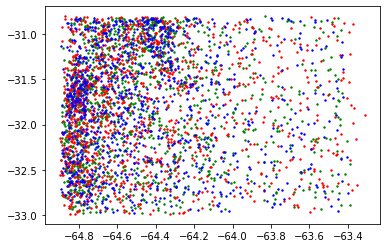

In [18]:
plt.scatter(ds_d3_s['meanlon'].mean(dim='times'), ds_d3_s['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4_s['meanlon'].mean(dim='times'), ds_d4_s['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2_s['meanlon'].mean(dim='times'), ds_d2_s['meanlat'].mean(dim='times'), s=2, c='b')

In [19]:
# minlon_o = ds_o.meanlon.min(dim='times')
# maxlon_o = ds_o.meanlon.max(dim='times')
# minlat_o = ds_o.meanlat.min(dim='times')
# maxlat_o = ds_o.meanlat.max(dim='times')
# # # Subset d2 tracks that are within D4 boundary
# # dss_o = ds_o.where((minlon_o >= min(lon_range)) & (maxlon_o <= max(lon_range)) & \
# #                    (minlat_o >= min(lat_range)) & (maxlat_o <= max(lat_range)), drop=True)
# # # Renumber tracks to make it continuous
# # ntracks_o = dss_o.sizes['tracks']
# # dss_o['tracks'] = np.arange(0, ntracks_o)
# # print(f'Number of tracks (OBS): {ntracks_o}')

# track_idx = np.where(
#     (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
#     (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
#     (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) & \
#     (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
# )[0]
# # Subset tracks
# dsout = ds.isel(tracks=track_idx)

In [20]:
# # Get track min/max lat/lon
# minlon_d2 = ds_d2.meanlon.min(dim='times')
# maxlon_d2 = ds_d2.meanlon.max(dim='times')
# minlat_d2 = ds_d2.meanlat.min(dim='times')
# maxlat_d2 = ds_d2.meanlat.max(dim='times')
# # Subset d2 tracks that are within D4 boundary
# dss_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
#                     (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# # Renumber tracks to make it continuous
# ntracks_d2 = dss_d2.sizes['tracks']
# dss_d2['tracks'] = np.arange(0, ntracks_d2)
# print(f'Number of tracks (D2): {ntracks_d2}')

In [21]:
# Cell max reflectivity
maxdbz_o = ds_o_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_o = ds_o_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_o = ds_o_s['cell_area'].load()
celldiam_o = 2 * np.sqrt(cellarea_o / np.pi)
# Cell min Tb
minTb_o = ds_o_s['temperature_ir_min'].load()

In [22]:
# Cell max reflectivity
maxdbz_o25 = ds_o25_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_o25 = ds_o25_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_o25 = ds_o25_s['cell_area'].load()
celldiam_o25 = 2 * np.sqrt(cellarea_o25 / np.pi)
# Cell min Tb
minTb_o25 = ds_o25_s['temperature_ir_min'].load()

In [23]:
# Cell max reflectivity
maxdbz_d2 = ds_d2_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = ds_d2_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = ds_d2_s['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
# Cell min Tb
minTb_d2 = ds_d2_s['temperature_ir_min'].load()

In [24]:
# Cell max reflectivity
maxdbz_d3 = ds_d3_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d3 = ds_d3_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_d3 = ds_d3_s['cell_area'].load()
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
# Cell min Tb
minTb_d3 = ds_d3_s['temperature_ir_min'].load()

In [25]:
# Cell max reflectivity
maxdbz_d4 = ds_d4_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d4 = ds_d4_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_d4 = ds_d4_s['cell_area'].load()
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Cell min Tb
minTb_d4 = ds_d4_s['temperature_ir_min'].load()

In [26]:
# # Set Seaborn plot style
# sns.set_theme('talk', style='whitegrid', font_scale=1.3, 
#               rc={'lines.linewidth':5, 'font.family':'Helvetica', 'axes.edgecolor':'k', 'grid.linestyle':'--'})

In [27]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [28]:
def plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname,
                   lcolors=None, legend_labels=None, legend_loc='lower right', cmap='Blues', fontsize=None):
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize
    lw_fit = 5
    
    g = sns.JointGrid(height=8, ratio=5, space=.3, marginal_ticks=False, xlim=xlim, ylim=ylim)

    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    cmap = truncate_colormap(cmap, 0.1, 1)
    sns.kdeplot(x=x_obs, y=y_obs, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=g.ax_joint)
    sns.kdeplot(x=x_m1, y=y_m1, color=lcolors['model'], levels=levels, fill=False, ax=g.ax_joint)
    sns.kdeplot(x=x_obs, color=lcolors['obs'], ax=g.ax_marg_x)
    sns.kdeplot(x=x_m1, color=lcolors['model'], ax=g.ax_marg_x)
    sns.kdeplot(y=y_obs, color=lcolors['obs'], ax=g.ax_marg_y)
    sns.kdeplot(y=y_m1, color=lcolors['model'], ax=g.ax_marg_y)
    
    # Linear regression (OBS)
    mask = ~np.isnan(x_obs) & ~np.isnan(y_obs)
    linfit = linregress(x=x_obs[mask], y=y_obs[mask])
    # yfit line values
    xfit = np.linspace(np.nanmin(x_obs), np.nanmax(x_obs), 100)
    yfit = linfit[0] * xfit + linfit[1]
    yfit_label = f"Corr: {linfit[2]:.02f}"
    g.ax_joint.plot(xfit, yfit, color=lcolors['obs'], lw=lw_fit, label=yfit_label, zorder=5)
    
    # Linear regression (m1)
    mask = ~np.isnan(x_m1) & ~np.isnan(y_m1)
    linfit = linregress(x=x_m1[mask], y=y_m1[mask])
    # yfit line values
    xfit = np.linspace(np.nanmin(x_m1), np.nanmax(x_m1), 100)
    yfit = linfit[0] * xfit + linfit[1]
    yfit_label = f"Corr: {linfit[2]:.02f}"
    g.ax_joint.plot(xfit, yfit, color=lcolors['model'], lw=lw_fit, label=yfit_label, zorder=5)
    
    # Legends
    legend_elements = [mpl.patches.Patch(facecolor=lcolors['obs'], edgecolor='b'),
                       mpl.lines.Line2D([0], [0], color=lcolors['model'])]
    leg = mpl.legend.Legend(g.ax_joint, handles=legend_elements, labels=legend_labels, 
                            loc=legend_loc, facecolor='w', prop={'family':'Helvetica', 'size':18})
    g.ax_joint.text(0.02, 0.95, annotate_text, ha='left', va='center', transform=g.ax_joint.transAxes)
    g.ax_joint.add_artist(leg)
    g.set_axis_labels(xlabel=xlabel, ylabel=ylabel)
    g.ax_marg_x.set_ylabel('')
    g.ax_marg_y.set_xlabel('')

    # g.savefig(figname, dpi=300, facecolor='w')
    # sns.JointGrid(marginal_ticks=True)
    return g

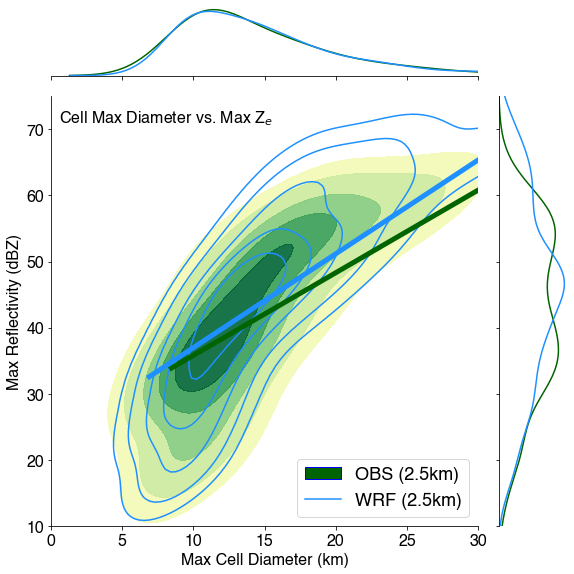

In [29]:
x_obs, y_obs = celldiam_o25.max(dim='times').data, maxdbz_o25.max(dim='times').data
x_m, y_m = celldiam_d2.max(dim='times').data, maxdbz_d2.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,30)
ylim = (10,75)
xlabel = 'Max Cell Diameter (km)'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = 'Cell Max Diameter vs. Max Z$_e$'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
cmap = 'YlGn'
fontsize = 16
figname = f'{figdir}KDE_MaxDiam_MaxDBZ_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap, fontsize=fontsize)

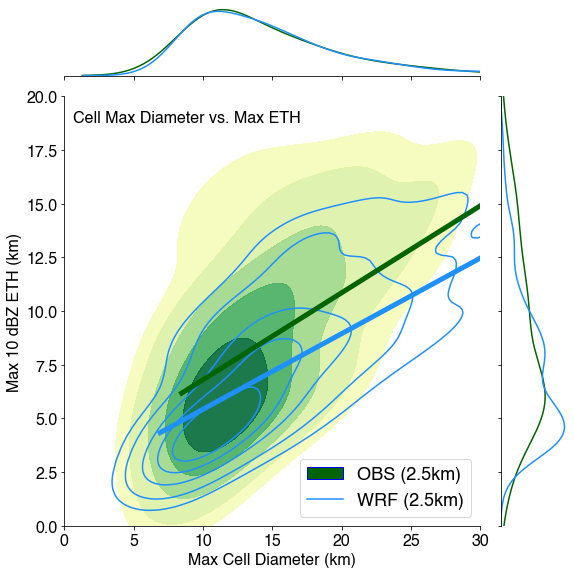

In [30]:
x_obs, y_obs = celldiam_o25.max(dim='times').data, maxETH_10dbz_o25.max(dim='times').data
x_m, y_m = celldiam_d2.max(dim='times').data, maxETH_10dbz_d2.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,30)
ylim = (0,20)
xlabel = 'Max Cell Diameter (km)'
ylabel = 'Max 10 dBZ ETH (km)'
annotate_text = 'Cell Max Diameter vs. Max ETH'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
fontsize = 16
figname = f'{figdir}KDE_MaxDiam_MaxETH10dBZ_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap, fontsize=fontsize)

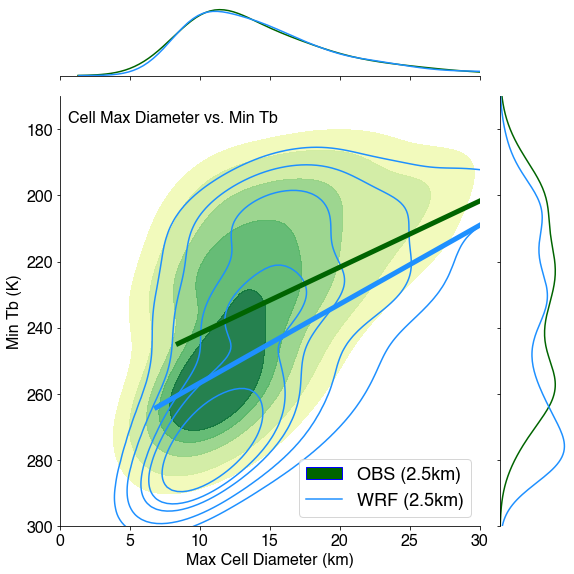

In [31]:
x_obs, y_obs = celldiam_o25.max(dim='times').data, minTb_o25.min(dim='times').data
x_m, y_m = celldiam_d2.max(dim='times').data, minTb_d2.min(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,30)
ylim = (300,170)
xlabel = 'Max Cell Diameter (km)'
ylabel = 'Min Tb (K)'
annotate_text = 'Cell Max Diameter vs. Min Tb'
lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
fontsize = 16
figname = f'{figdir}KDE_MaxDiam_MinTb_d2.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, cmap=cmap, fontsize=fontsize)

## Function to plot MxN panel JointKDE 

In [32]:
def jointKDE_MxN(nrow, ncol, data, margin_space=0.01, levels=None, cmap=None, lcolors=None, suptitle=None, fontsize=None,
                 titles=None, xlims=None, ylims=None, xlabels=None, ylabels=None, 
                 legend_loc='best', legend_labels=None, legend_fs=None,
                 dpi=300, figsize=None, figname=None):
    
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize

    if figsize is None: figsize=(6 * ncol, 6 * nrow)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = gridspec.GridSpec(nrow, ncol, wspace=0.5, hspace=0.5)
    
    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    lw_joint = 2
    lw_fit = 5

    # Create a KDE plot with marginals for each cell in the grid
    for row in range(nrow):
        for col in range(ncol):
            # idx = i * ncol + j
            # x, y = data[idx]
            if (data[row][col] is not None):
                x_o, y_o = data[row][col]['o']
                x_m, y_m = data[row][col]['m']
                if (col==0): lc_m = lcolors['m1']
                if (col==1): lc_m = lcolors['m2']
                if (col==2): lc_m = lcolors['m3']
                # legend_lab = legend_labels[row][col]
                # legend_m = legend_labels[row][col]

                # Set up main axes for joint KDE plot in the GridSpec layout
                ax_joint = fig.add_subplot(gs[row, col])

                # Plot joint KDE
                sns.kdeplot(x=x_o, y=y_o, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=ax_joint)
                sns.kdeplot(x=x_m, y=y_m, color=lc_m, levels=levels, linewidths=lw_joint, fill=False, ax=ax_joint)
                ax_joint.set_xlabel(xlabels[row][col])
                ax_joint.set_ylabel(ylabels[row][col])
                ax_joint.grid(ls=':')
                
                # Linear regression (OBS)
                mask = ~np.isnan(x_o) & ~np.isnan(y_o)
                linfit = linregress(x=x_o[mask], y=y_o[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_o), np.nanmax(x_o), 100)
                yfit = linfit[0] * xfit + linfit[1]
                yfit_label_o = f"Corr: {linfit[2]:.02f}, Slope: {linfit[0]:.02f}"
                ax_joint.plot(xfit, yfit, color=lcolors['o'], lw=lw_fit, label=yfit_label_o, zorder=5)

                # Linear regression (m1)
                mask = ~np.isnan(x_m) & ~np.isnan(y_m)
                linfit = linregress(x=x_m[mask], y=y_m[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_m), np.nanmax(x_m), 100)
                yfit = linfit[0] * xfit + linfit[1]
                yfit_label_m = f"Corr: {linfit[2]:.02f}, Slope: {linfit[0]:.02f}"
                ax_joint.plot(xfit, yfit, color=lc_m, lw=lw_fit, label=yfit_label_m, zorder=5)
                
                # Create marginal axes with a small space between them and ax_joint
                pos = ax_joint.get_position()
                ax_marg_x = fig.add_axes([pos.x0, pos.y1 + margin_space, pos.width, 0.2 * pos.height])
                ax_marg_y = fig.add_axes([pos.x1 + margin_space, pos.y0, 0.2 * pos.width, pos.height])
                ax_marg_x.grid(axis='x', ls=':')
                ax_marg_y.grid(axis='y', ls=':')
                
                # Set x and y limits for ax_joint and apply to the marginal plots
                if xlims:
                    ax_joint.set_xlim(xlims[row][col])
                    ax_marg_x.set_xlim(xlims[row][col])
                if ylims:
                    ax_joint.set_ylim(ylims[row][col])
                    ax_marg_y.set_ylim(ylims[row][col])

                # Plot marginal KDEs on the marginal axes
                sns.kdeplot(x=x_o, ax=ax_marg_x, color=lcolors['o'], lw=lw_joint, fill=False)
                sns.kdeplot(y=y_o, ax=ax_marg_y, color=lcolors['o'], lw=lw_joint, fill=False)
                sns.kdeplot(x=x_m, ax=ax_marg_x, color=lc_m, lw=lw_joint, fill=False)
                sns.kdeplot(y=y_m, ax=ax_marg_y, color=lc_m, lw=lw_joint, fill=False)
                
                # # Adjust ylim of marginal plots to avoid cutting off the KDE line
                # y_lim_x = ax_marg_x.get_ylim()
                # ax_marg_x.set_ylim(y_lim_x[0] * 1.1, y_lim_x[1] * 1.1)  # Increase upper limit by 10%
                # y_lim_y = ax_marg_y.get_xlim()
                # ax_marg_y.set_xlim(y_lim_y[0] * 1.1, y_lim_y[1] * 1.1)  # Increase upper limit by 10%
                
                # Add title within the ax_joint at the upper left corner
                ax_joint.text(
                    0.02, 0.98,  # Position in axis coordinates
                    titles[row][col],
                    ha='left', va='top',
                    transform=ax_joint.transAxes,
                    # fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                )
                
                # Legends
                # ax_joint.legend(loc=legend_loc)
                legend_elements = [mpl.patches.Patch(facecolor=cmap(0.1), edgecolor='gray'),
                                   mpl.lines.Line2D([0], [0], color=lc_m, lw=lw_joint)]
                _legend_labels = [f"{legend_labels[row][col][0]} ({yfit_label_o})",
                                  f"{legend_labels[row][col][1]} ({yfit_label_m})"]
                ax_joint.legend(handles=legend_elements, labels=_legend_labels, 
                                loc=legend_loc, facecolor='w', fontsize=legend_fs,
                                # prop={'family':'Helvetica', 'size':18},
                               )

                # Remove tick labels and borders on the marginal plots
                ax_marg_x.set(yticks=[], ylabel=None)
                ax_marg_x.set_xticklabels([])  # Remove x-axis tick labels
                ax_marg_y.set(xticks=[], xlabel=None)
                ax_marg_y.set_yticklabels([])  # Remove y-axis tick labels
                ax_marg_x.tick_params(left=False, bottom=False)
                ax_marg_y.tick_params(left=False, bottom=False)
                # Show only the bottom spine (x-axis) for ax_marg_x and left spine (y-axis) for ax_marg_y
                ax_marg_x.spines['top'].set_visible(False)
                ax_marg_x.spines['right'].set_visible(False)
                ax_marg_x.spines['left'].set_visible(False)
                ax_marg_y.spines['top'].set_visible(False)
                ax_marg_y.spines['right'].set_visible(False)
                ax_marg_y.spines['bottom'].set_visible(False)
                # # Hide all spines
                # for spine in ax_marg_x.spines.values():
                #     spine.set_visible(False)
                # for spine in ax_marg_y.spines.values():
                #     spine.set_visible(False)

    if (suptitle): fig.suptitle(suptitle, weight='bold')
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

2 3
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation/JointKDE_MaxDiam_MaxETH10dBZ_MinTb_obs_d2_d3_d4.png


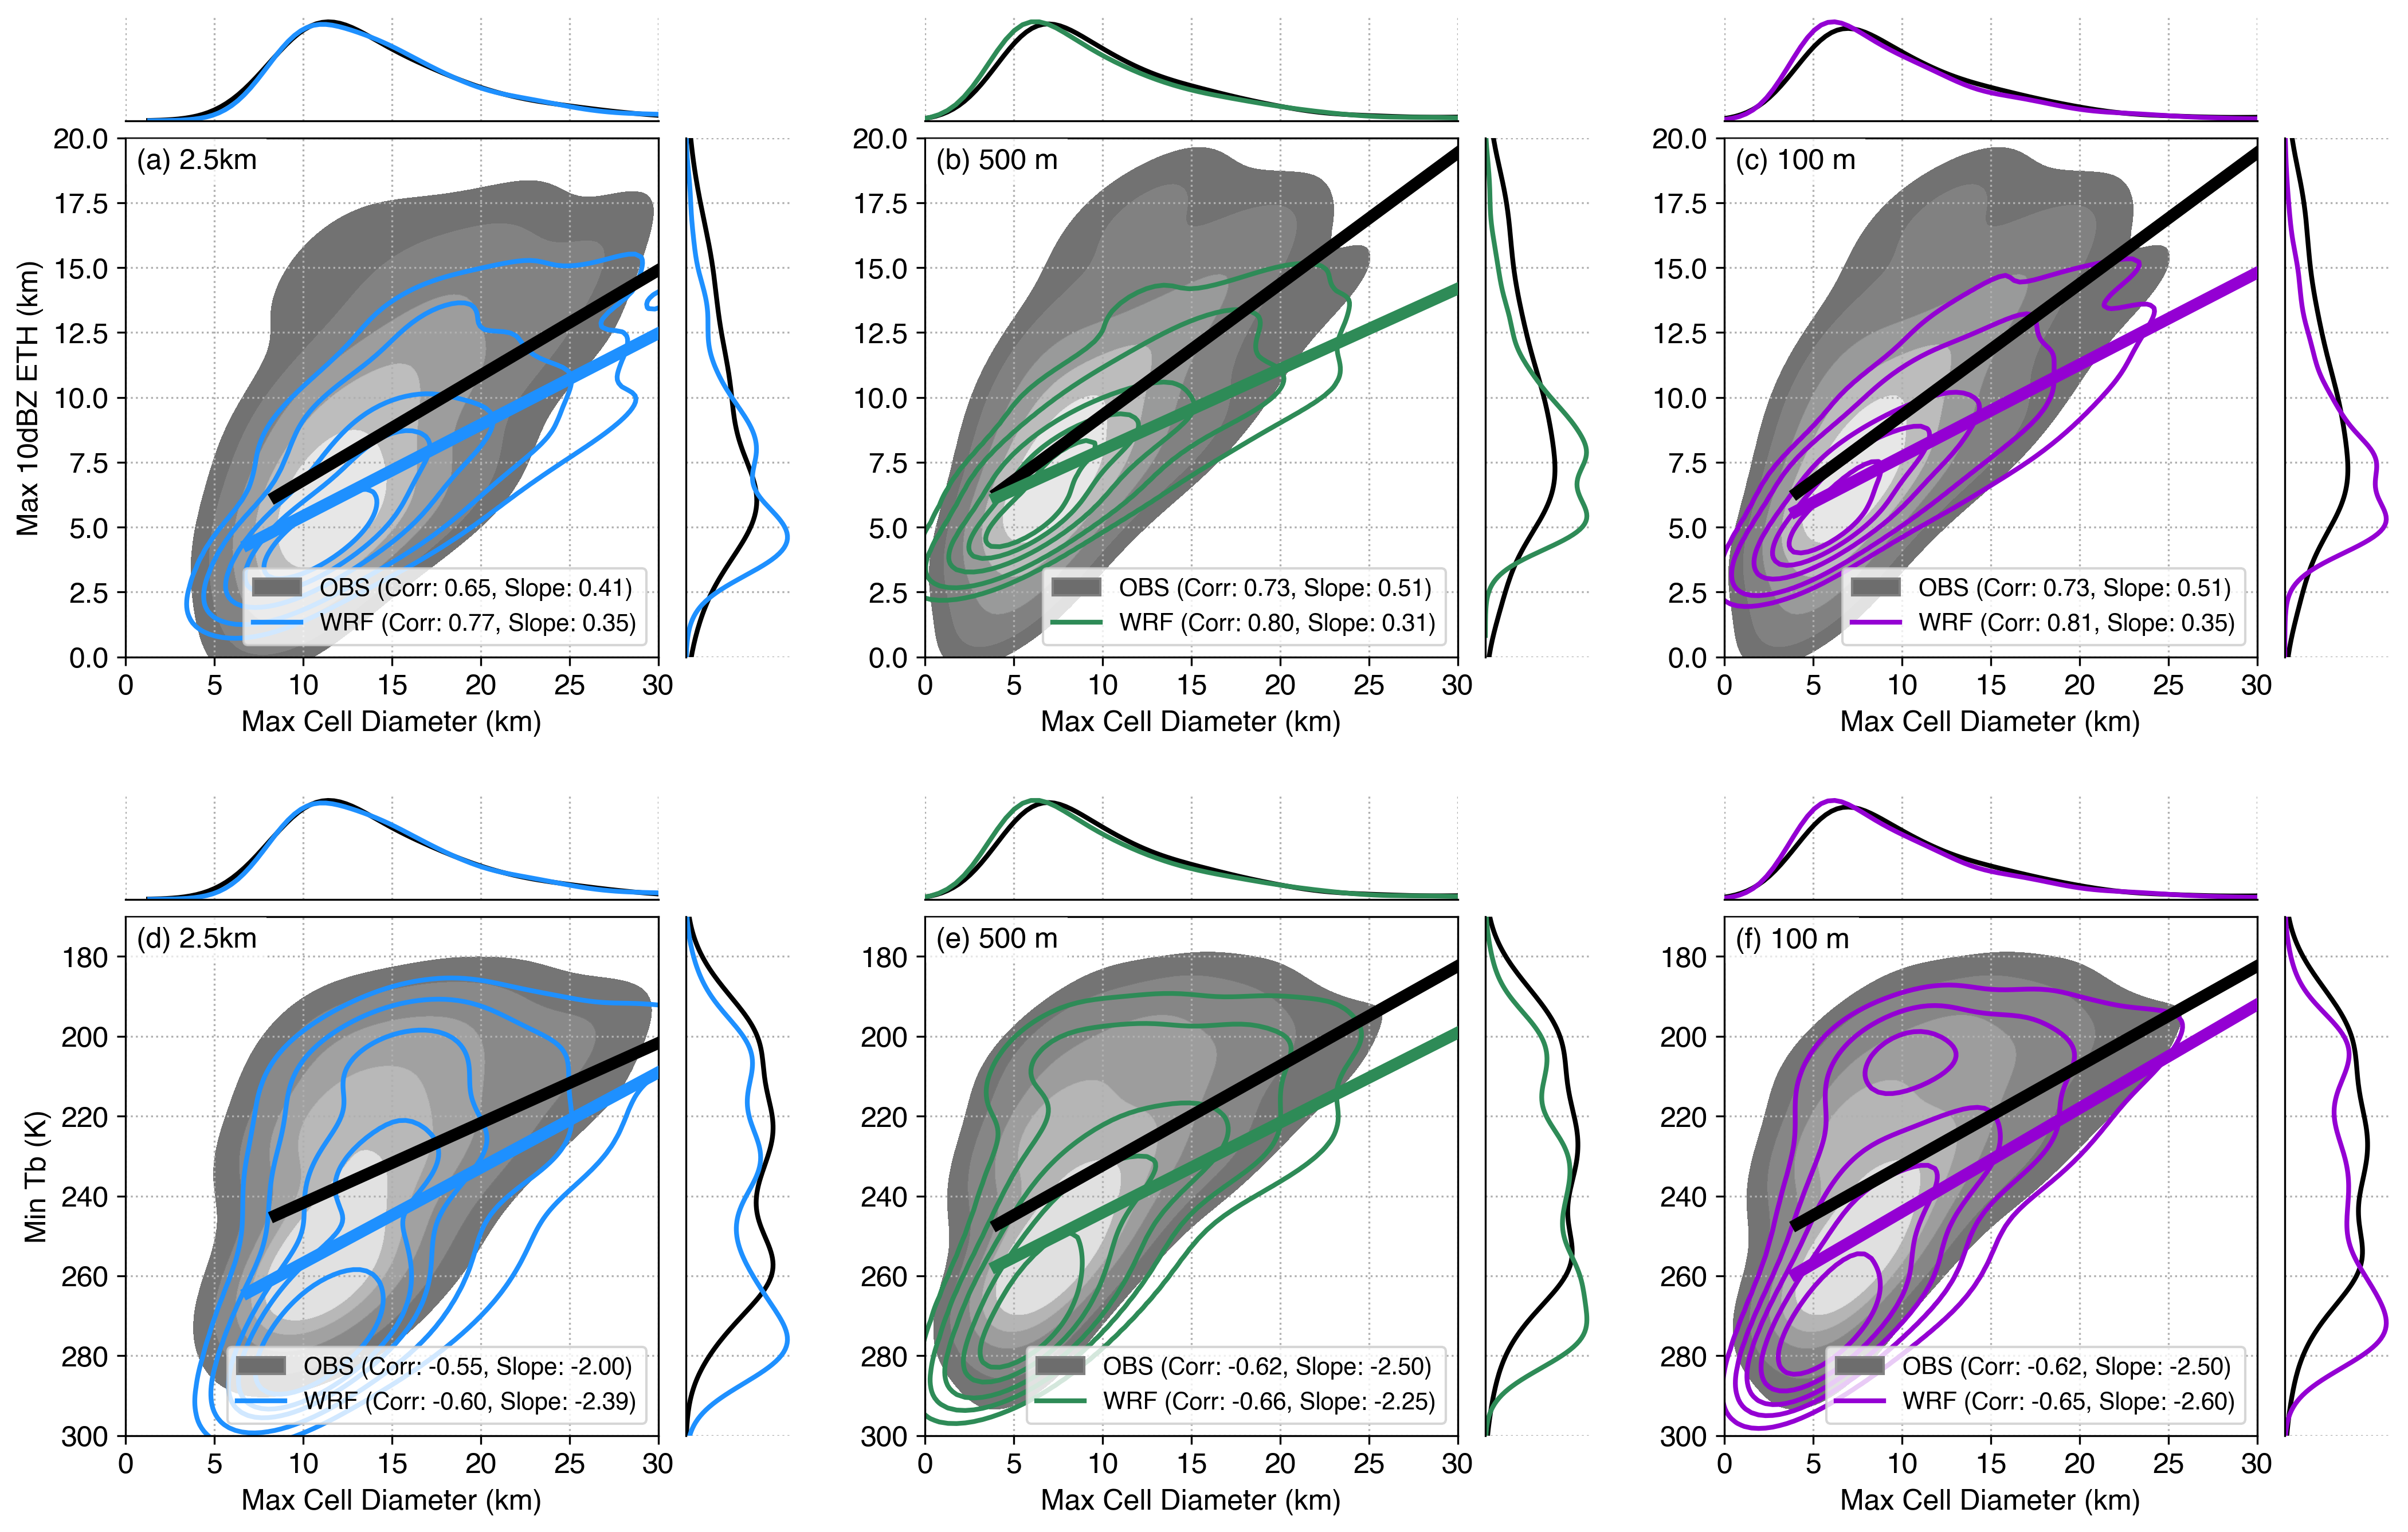

In [42]:
data_arr = [
    [{'o':[celldiam_o25.max(dim='times').data, maxETH_10dbz_o25.max(dim='times').data], 
      'm':[celldiam_d2.max(dim='times').data, maxETH_10dbz_d2.max(dim='times').data]},
     {'o':[celldiam_o.max(dim='times').data, maxETH_10dbz_o.max(dim='times').data], 
      'm':[celldiam_d3.max(dim='times').data, maxETH_10dbz_d3.max(dim='times').data]},
     {'o':[celldiam_o.max(dim='times').data, maxETH_10dbz_o.max(dim='times').data], 
      'm':[celldiam_d4.max(dim='times').data, maxETH_10dbz_d4.max(dim='times').data]},
    ],
    [{'o':[celldiam_o25.max(dim='times').data, minTb_o25.min(dim='times').data], 
      'm':[celldiam_d2.max(dim='times').data, minTb_d2.min(dim='times').data]},
     {'o':[celldiam_o.max(dim='times').data, minTb_o.min(dim='times').data], 
      'm':[celldiam_d3.max(dim='times').data, minTb_d3.min(dim='times').data]},
     {'o':[celldiam_o.max(dim='times').data, minTb_o.min(dim='times').data], 
      'm':[celldiam_d4.max(dim='times').data, minTb_d4.min(dim='times').data]},
    ],
]
nrow = len(data_arr)
ncol = len(data_arr[0])
print(nrow, ncol)

xlims = [[(0,30)]*ncol, [(0,30)]*ncol]
ylims = [[(0,20)]*ncol, [(300,170)]*ncol]

cmap = cc.cm['CET_L1']
cmap = truncate_colormap(cmap, 0.4, 1)
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlabels = [['Max Cell Diameter (km)']*ncol, ['Max Cell Diameter (km)']*ncol]
ylabels = [['Max 10dBZ ETH (km)','',''], ['Min Tb (K)','','']]
titles = [['(a) 2.5km', '(b) 500 m', '(c) 100 m'], ['(d) 2.5km', '(e) 500 m', '(f) 100 m']]
lcolors = {'o':'k', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
legend_labels = [
    [['OBS', 'WRF'],['OBS', 'WRF'],['OBS','WRF'],],
    [['OBS', 'WRF'],['OBS', 'WRF'],['OBS','WRF'],],
]
legend_loc = 'lower right'
legend_fs = 10
fontsize = 12
figsize = (16,10)
# suptitle = 'Cell Max Diameter vs. Max ETH'
suptitle = None
margin_space = 0.01
figname = f'{figdir}JointKDE_MaxDiam_MaxETH10dBZ_MinTb_obs_d2_d3_d4.png'
# figname = f'{figdir}JointKDE_MaxDiam_MaxETH10dBZ_MinTb_obs_d2_d3_d4.pdf'
print(figname)
fig = jointKDE_MxN(nrow, ncol, data_arr, margin_space=margin_space, levels=levels, cmap=cmap, lcolors=lcolors, suptitle=suptitle, 
                   titles=titles, xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, legend_labels=legend_labels, legend_loc=legend_loc, legend_fs=legend_fs,
                   fontsize=fontsize, figsize=figsize, figname=figname,)

In [34]:
# data_arr = [
#     [{'o':[celldiam_o25.max(dim='times').data, minTb_o25.min(dim='times').data], 
#       'm':[celldiam_d2.max(dim='times').data, minTb_d2.min(dim='times').data]},
#      {'o':[celldiam_o.max(dim='times').data, minTb_o.min(dim='times').data], 
#       'm':[celldiam_d3.max(dim='times').data, minTb_d3.min(dim='times').data]},
#      {'o':[celldiam_o.max(dim='times').data, minTb_o.min(dim='times').data], 
#       'm':[celldiam_d4.max(dim='times').data, minTb_d4.min(dim='times').data]},
#     ],
# ]
# nrow = len(data_arr)
# ncol = len(data_arr[0])
# print(nrow, ncol)

# xlims = [[(0,30)]*ncol]
# ylims = [[(300,170)]*ncol]

# # cmap = 'YlGn'
# cmap = cc.cm['CET_L1']
# cmap = truncate_colormap(cmap, 0.4, 1)
# levels = [0.1,0.2,0.4,0.6,0.8,1]
# xlabels = [['Max Cell Diameter (km)']*ncol]
# ylabels = [['Min Tb (K)','','']]
# titles = [['(a) 2.5km', '(b) 500 m', '(c) 100 m']]
# lcolors = {'o':'k', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
# # lcolors = {'o':'darkgreen', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
# legend_labels = [
#     [['OBS', 'WRF'],['OBS', 'WRF'],['OBS','WRF'],],
#     # [['OBS (2.5km)', 'WRF (2.5km)'],['OBS (500m)', 'WRF (500m)'],['OBS (500m)','WRF (100m)'],],
# ]
# legend_loc = 'lower right'
# legend_fs = 10
# fontsize = 14
# figsize = (16,4)
# # suptitle = 'Cell Max Diameter vs. Min Tb'
# suptitle = None
# margin_space = 0.01
# figname = f'{figdir}JointKDE_MaxDiam_MinTb_obs_d2_d3_d4.png'
# fig = jointKDE_MxN(nrow, ncol, data_arr, margin_space=margin_space, levels=levels, cmap=cmap, lcolors=lcolors, suptitle=suptitle, 
#                    titles=titles, xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, 
#                    legend_labels=legend_labels, legend_loc=legend_loc, legend_fs=legend_fs,
#                    fontsize=fontsize, figsize=figsize, figname=figname,)

In [35]:
# data_arr = [
#     [{'o':[celldiam_o25.max(dim='times').data, maxETH_10dbz_o25.max(dim='times').data], 
#       'm':[celldiam_d2.max(dim='times').data, maxETH_10dbz_d2.max(dim='times').data]},
#      {'o':[celldiam_o.max(dim='times').data, maxETH_10dbz_o.max(dim='times').data], 
#       'm':[celldiam_d3.max(dim='times').data, maxETH_10dbz_d3.max(dim='times').data]},
#      {'o':[celldiam_o.max(dim='times').data, maxETH_10dbz_o.max(dim='times').data], 
#       'm':[celldiam_d4.max(dim='times').data, maxETH_10dbz_d4.max(dim='times').data]},
#     ],
# ]
# nrow = len(data_arr)
# ncol = len(data_arr[0])
# print(nrow, ncol)

# xlims = [[(0,30)]*ncol]
# ylims = [[(0,20)]*ncol]

# # cmap = 'YlGn'
# cmap = cc.cm['CET_L1']
# cmap = truncate_colormap(cmap, 0.4, 1)
# levels = [0.1,0.2,0.4,0.6,0.8,1]
# xlabels = [['Max Cell Diameter (km)']*ncol]
# ylabels = [['Max 10dBZ ETH (km)','','']]
# titles = [['(a)', '(b)','(c)']]
# lcolors = {'o':'k', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
# # lcolors = {'o':'darkgreen', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
# legend_labels = [
#     [['OBS (2.5km)', 'WRF (2.5km)'],['OBS (500m)', 'WRF (500m)'],['OBS (500m)','WRF (100m)'],],
# ]
# legend_loc = 'lower right'
# fontsize = 14
# figsize = (16,4)
# # suptitle = 'Cell Max Diameter vs. Max ETH'
# suptitle = None
# margin_space = 0.01
# figname = f'{figdir}JointKDE_MaxDiam_MaxETH10dBZ_obs_d2_d3_d4.png'
# fig = jointKDE_MxN(nrow, ncol, data_arr, margin_space=margin_space, levels=levels, cmap=cmap, lcolors=lcolors, suptitle=suptitle, 
#                    titles=titles, xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, legend_labels=legend_labels, legend_loc=legend_loc,
#                    fontsize=fontsize, figsize=figsize, figname=figname,)

1 3


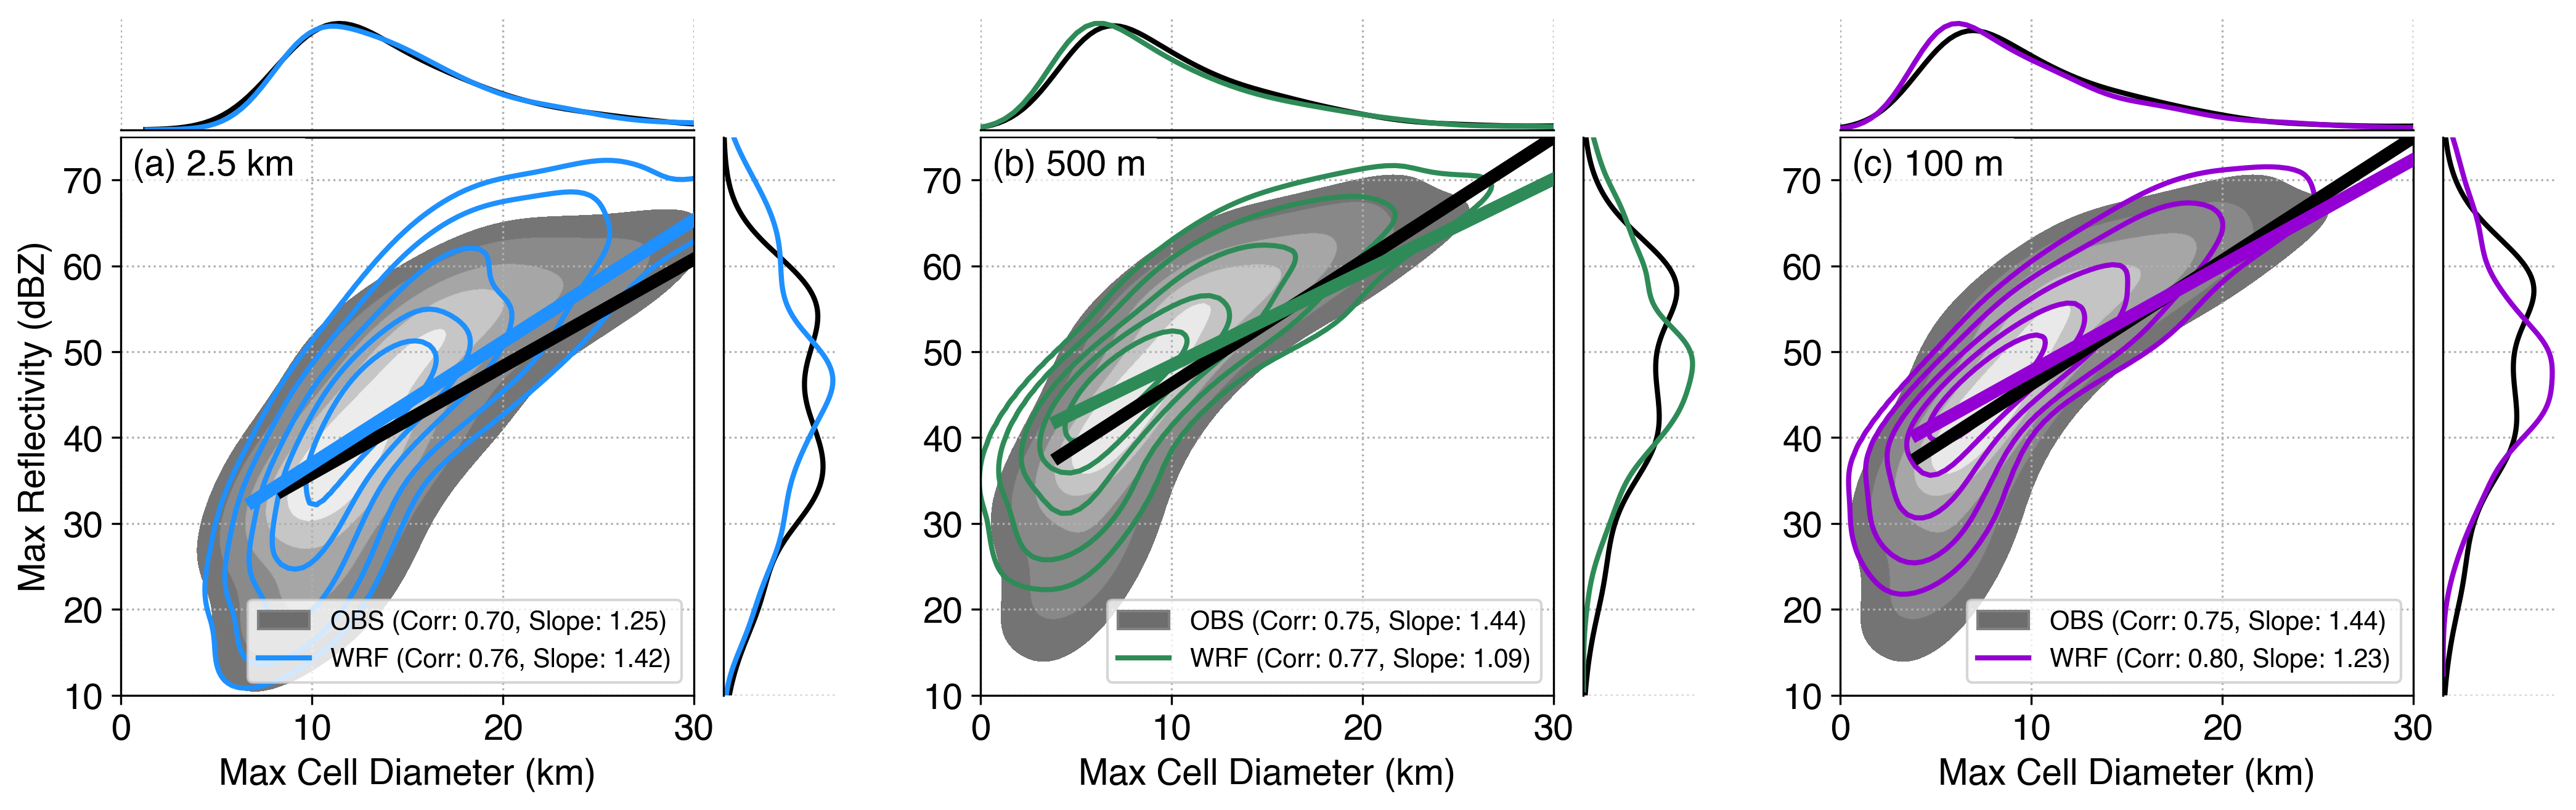

In [36]:
data_arr = [
    [{'o':[celldiam_o25.max(dim='times').data, maxdbz_o25.max(dim='times').data], 
      'm':[celldiam_d2.max(dim='times').data, maxdbz_d2.max(dim='times').data]},
     {'o':[celldiam_o.max(dim='times').data, maxdbz_o.max(dim='times').data], 
      'm':[celldiam_d3.max(dim='times').data, maxdbz_d3.max(dim='times').data]},
     {'o':[celldiam_o.max(dim='times').data, maxdbz_o.max(dim='times').data], 
      'm':[celldiam_d4.max(dim='times').data, maxdbz_d4.max(dim='times').data]},
    ],
]
nrow = len(data_arr)
ncol = len(data_arr[0])
print(nrow, ncol)

xlims = [[(0,30)]*ncol]
ylims = [[(10,75)]*ncol]

# cmap = 'YlGn'
cmap = cc.cm['CET_L1']
cmap = truncate_colormap(cmap, 0.4, 1)
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlabels = [['Max Cell Diameter (km)']*ncol]
ylabels = [['Max Reflectivity (dBZ)','','']]
titles = [['(a) 2.5 km', '(b) 500 m', '(c) 100 m']]
lcolors = {'o':'k', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
legend_labels = [
    [['OBS', 'WRF'],['OBS', 'WRF'],['OBS','WRF'],],
]
legend_loc = 'lower right'
legend_fs = 10
fontsize = 14
figsize = (16,4)
suptitle = None
margin_space = 0.01
figname = f'{figdir}JointKDE_MaxDiam_MaxReflectivity_obs_d2_d3_d4.png'
fig = jointKDE_MxN(nrow, ncol, data_arr, margin_space=margin_space, levels=levels, cmap=cmap, lcolors=lcolors, suptitle=suptitle, 
                   titles=titles, xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, legend_labels=legend_labels, legend_loc=legend_loc, legend_fs=legend_fs,
                   fontsize=fontsize, figsize=figsize, figname=figname,)

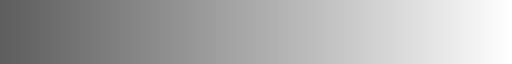

In [37]:
# cmap = truncate_colormap(cc.cm['CET_L4'], 0.1, 1)
# cmap
# cmap = cc.cm['CET_L4']
cmap = cc.cm['CET_L1']
cmap = truncate_colormap(cmap, 0.4, 1)
cmap

In [38]:
cmap(0.1)

(0.42592, 0.42601, 0.42599, 1.0)

In [39]:
# x_obs, y_obs = celldiam_o25.max(dim='times').data, minTb_o25.min(dim='times').data
# x_m, y_m = celldiam_d2.max(dim='times').data, minTb_d2.min(dim='times').data
# levels = [0.1,0.2,0.4,0.6,0.8,1]
# xlim = (0,30)
# ylim = (300,170)
# xlabel = 'Max Cell Diameter (km)'
# ylabel = 'Min Tb (K)'
# annotate_text = 'Cell Max Diameter vs. Min Tb'
# lcolors = {'obs':'darkgreen', 'model':'dodgerblue'}
# legend_labels = ['OBS (2.5km)', 'WRF (2.5km)']
# fontsize = 16
# figname = f'{figdir}KDE_MaxDiam_MinTb_d2.png'
# g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
#                    lcolors=lcolors, legend_labels=legend_labels, cmap=cmap, fontsize=fontsize)

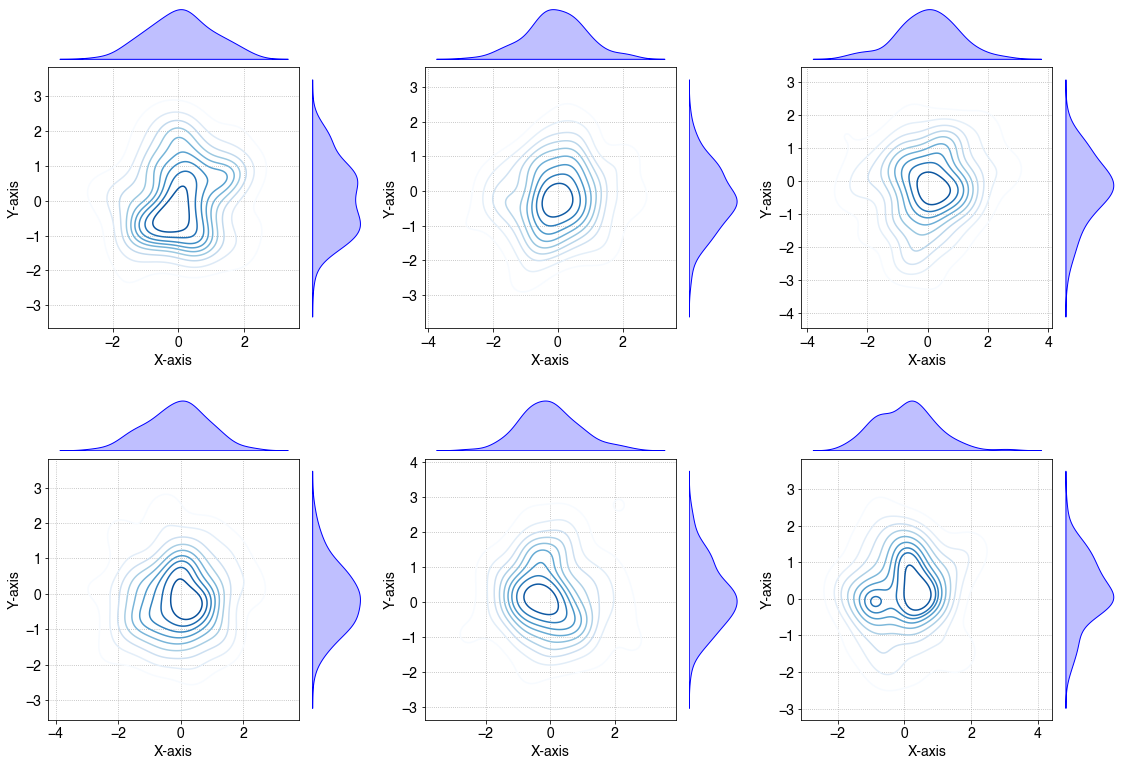

In [40]:
# Sample data generator for multiple panels
def generate_data(n):
    np.random.seed(0)
    return [(np.random.normal(size=100), np.random.normal(size=100)) for _ in range(n)]

# Generalized function to create an MxN grid of KDE panels with marginals
def kde_panel_grid(M, N, margin_space=0.02):
    fig = plt.figure(figsize=(6 * N, 6 * M))
    gs = gridspec.GridSpec(M, N, wspace=0.5, hspace=0.5)
    data = generate_data(M * N)  # Generate sample data for each panel

    # Create a KDE plot with marginals for each cell in the grid
    for i in range(M):
        for j in range(N):
            idx = i * N + j
            x, y = data[idx]
            
            # Set up main axes for joint KDE plot in the GridSpec layout
            ax_joint = fig.add_subplot(gs[i, j])
            
            # Plot joint KDE
            sns.kdeplot(x=x, y=y, ax=ax_joint, cmap="Blues")
            ax_joint.set_xlabel('X-axis')
            ax_joint.set_ylabel('Y-axis')
            ax_joint.grid(ls=':')

            # Create marginal axes with a small space between them and ax_joint
            pos = ax_joint.get_position()
            ax_marg_x = fig.add_axes([pos.x0, pos.y1 + margin_space, pos.width, 0.2 * pos.height])
            ax_marg_y = fig.add_axes([pos.x1 + margin_space, pos.y0, 0.2 * pos.width, pos.height])

            # Plot marginal KDEs on the marginal axes
            sns.kdeplot(x=x, ax=ax_marg_x, color="blue", fill=True)
            sns.kdeplot(y=y, ax=ax_marg_y, color="blue", fill=True)

            # Remove tick labels and borders on the marginal plots
            ax_marg_x.set(yticks=[], ylabel=None)
            ax_marg_x.set_xticklabels([])  # Remove x-axis tick labels
            ax_marg_y.set(xticks=[], xlabel=None)
            ax_marg_y.set_yticklabels([])  # Remove y-axis tick labels
            ax_marg_x.tick_params(left=False, bottom=False)
            ax_marg_y.tick_params(left=False, bottom=False)
            for spine in ax_marg_x.spines.values():
                spine.set_visible(False)
            for spine in ax_marg_y.spines.values():
                spine.set_visible(False)

    plt.show()

# Create a 2x3 grid of KDE panels with marginals, adding a small space
kde_panel_grid(2, 3, margin_space=0.01)